# Model selection

Le but fondamental est d'apprendre, à partir d'un ensemble de données étiquetées $\mathcal{D}$ , une fonction $f$ capable de prédire correctement les étiquettes d'échantillons jamais vus auparavant.

**Risque Réel $R(f)$**: C'est l'erreur moyenne attendue sur toutes les données futures possibles. Comme on ne connaît pas la loi de probabilité globale des données, il est incalculable et représente l'objectif idéal de généralisation.  
**Risque Empirique $R_{n}(f)$**: C'est l'erreur moyenne calculée uniquement sur les données d'apprentissage disponibles3. C'est une approximation du risque réel, mais un score de 0 ici peut signifier que le modèle a "appris par cœur" sans pouvoir généraliser (sur-apprentissage)4444.

## 1 Splice classification

In [43]:
from sklearn.datasets import load_svmlight_file
import numpy as np
X, Y = load_svmlight_file("./splice")
print(f"nombre de samples: {X.shape[0]}, nombre de features: {X.shape[1]}\n")
Y[Y < 0] = 0
unique, count = np.unique(Y, return_counts=True)
for u, c in zip(unique, count):
    print(f"classe {u}: {c} samples")
    pourcentage_classe1 = c/X.shape[0]
    print(f"pourcentage classe {u}: {pourcentage_classe1*100}%")
if pourcentage_classe1>0.45 and pourcentage_classe1<0.55:
    print("Il s'agit plutôt d'un problème de classification équilibré: on a presque la même quantité d'échantillon dans chaque classe")

nombre de samples: 1000, nombre de features: 60

classe 0.0: 483 samples
pourcentage classe 0.0: 48.3%
classe 1.0: 517 samples
pourcentage classe 1.0: 51.7%
Il s'agit plutôt d'un problème de classification équilibré: on a presque la même quantité d'échantillon dans chaque classe


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y,
                                                    shuffle=True, test_size=1/3)

gamma_grid = np.logspace(-3, 0, 25) 
C_grid = np.logspace(-1/2, 2, 25)

pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('svc', SVC(kernel="rbf"))
])
parameters = {
    'svc__C': C_grid, 
    'svc__gamma': gamma_grid
}
K = 5 
clf_rbf = GridSearchCV(pipe, param_grid=parameters, cv=K, 
                  scoring="accuracy", verbose=1, n_jobs=-1)
clf_rbf.fit(X_train, Y_train)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': array([ 0.31...100. ]), 'svc__gamma': array([0.001 ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [45]:
# si ça marche pas, tester: 
# parameters = [{"gamma": gamma_grid, "C": C_grid}]
# svc_rbf = SVC(kernel="rbf", tol=0.01)
# clf_rbf = GridSearchCV(svc_rbf, param_grid=parameters, cv=K, scoring="accuracy", verbose=1, n_jobs=2)

In [46]:
print("\n Rbf kernel - optimal hyper-parameters = {}".format(clf_rbf.best_params_))
print("\n Rbf kernel - best cross-val accuracy = {}".format(clf_rbf.best_score_))


 Rbf kernel - optimal hyper-parameters = {'svc__C': np.float64(3.4807005884284115), 'svc__gamma': np.float64(0.01778279410038923)}

 Rbf kernel - best cross-val accuracy = 0.8604197059813712


best_score_: représente une moyenne de risques empiriques calculés sur les différents plis (folds).

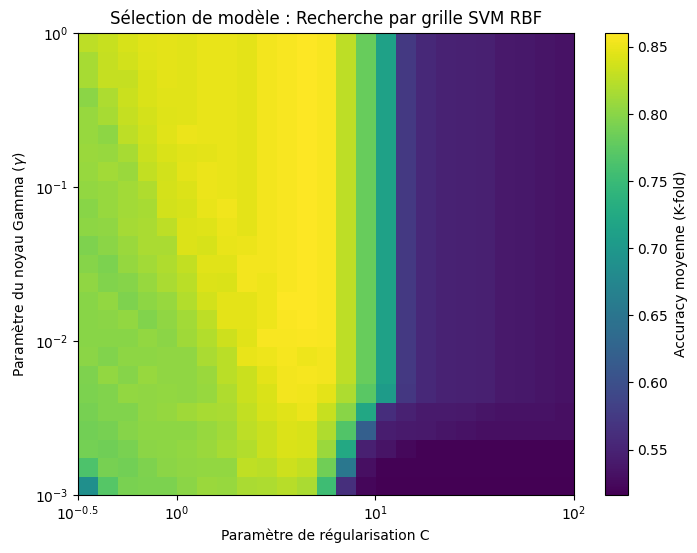

In [47]:
import matplotlib.pyplot as plt

scores = clf_rbf.cv_results_["mean_test_score"].reshape(len(C_grid), len(gamma_grid))
plt.figure(figsize=(8, 6))
plt.imshow(scores, 
           extent=[np.log10(C_grid.min()), np.log10(C_grid.max()), 
                   np.log10(gamma_grid.min()), np.log10(gamma_grid.max())],
           interpolation='nearest', aspect="auto", origin='lower')

# ersonnalisation des axes pour afficher les puissances
# Axe X (C): de 10^-0.5 à 10^2
c_ticks = [-0.5, 0, 1, 2]
c_labels = [r"$10^{-0.5}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"]

# Axe Y (Gamma): de 10^-3 à 10^0
gamma_ticks = [-3, -2, -1, 0]
gamma_labels = [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"]

plt.xticks(c_ticks, c_labels)
plt.yticks(gamma_ticks, gamma_labels)

plt.title("Sélection de modèle : Recherche par grille SVM RBF")
plt.xlabel("Paramètre de régularisation C")
plt.ylabel(r"Paramètre du noyau Gamma ($\gamma$)")
plt.colorbar(label="Accuracy moyenne (K-fold)")
plt.show()

- Zone optimale (Jaune) : Elle indique les meilleures performances (accuracy $\approx 0,85$) pour des valeurs de $C$ faibles ($10^{-0.5}$ à $10^1$).
- Sur-apprentissage (Violet) : Dès que $C > 10^1$, la performance chute brutalement3. Le modèle devient trop complexe et perd sa capacité de généralisation.
- Sous-apprentissage (Turquoise) : En bas à gauche ($\gamma = 10^{-3}$), la performance baisse légèrement car le modèle est trop simple pour capturer la structure des données.
- Action requise : La zone jaune touche le bord gauche ($C = 10^{-0.5}$), il faudrait tester des valeurs de $C$ encore plus petites pour s'assurer d'avoir trouvé le véritable maximum de généralisation.

In [48]:
unique, count = np.unique(Y_test, return_counts=True)
for u, c in zip(unique, count):
    print(f"classe {u}: {c} samples")
    pourcentage_classe1 = c/X_test.shape[0]
    print(f"pourcentage classe {u}: {pourcentage_classe1*100}%")

classe 0.0: 161 samples
pourcentage classe 0.0: 48.20359281437126%
classe 1.0: 173 samples
pourcentage classe 1.0: 51.796407185628745%


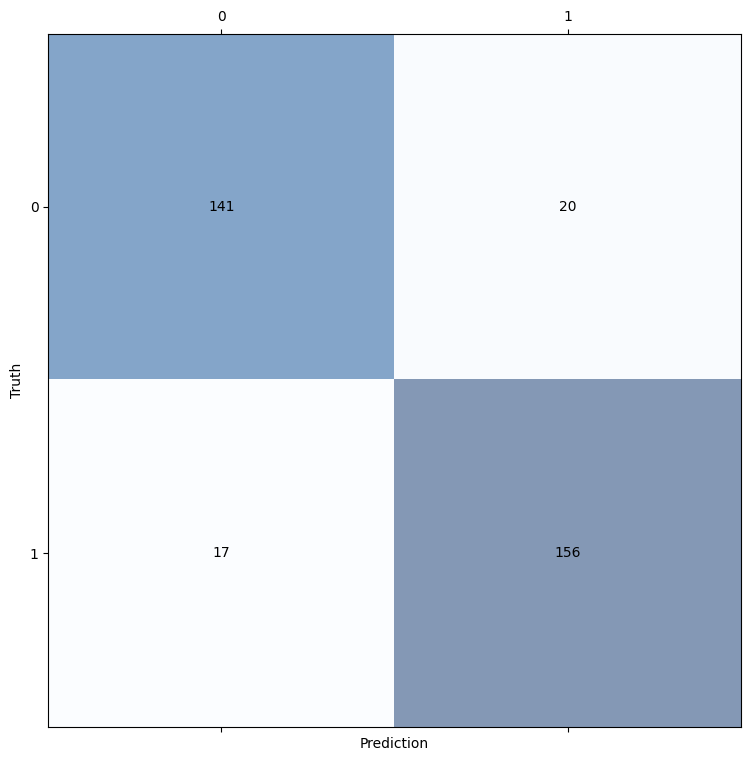

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score

# on utilise directement le meilleur modèle trouvé via le GridSearch précédent 
best_svc = clf_rbf.best_estimator_
Ytest_pred = best_svc.predict(X_test)
confmat = confusion_matrix(Y_test, Ytest_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.5)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va="center", ha="center")
plt.xlabel("Prediction"); plt.ylabel("Truth");

In [50]:
test_acc = accuracy_score(Y_test, Ytest_pred)
print(f"Prediction accuracy on the test set: {test_acc:.4f}")

Prediction accuracy on the test set: 0.8892


In [51]:
C_grid = np.logspace(-0.5, 2, 25) 

pipe_linear = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('svc', SVC(kernel="linear", tol=0.01))
])

parameters_linear = {'svc__C': C_grid}

clf_linear = GridSearchCV(pipe_linear, 
                          param_grid=parameters_linear, cv=3, scoring="accuracy", n_jobs=-1)
clf_linear.fit(X_train, Y_train)

accuracy_linear_cv = clf_linear.best_score_
accuracy_linear_test = accuracy_score(Y_test, clf_linear.predict(X_test))

# plot un graphique de la différence pour le taux d'erreur pour 
print(f"SVM Linéaire (Meilleure SVC): {accuracy_linear_cv:.4f}")
print(f"SVM Linéaire (Précision Test): {accuracy_linear_test:.4f}")

SVM Linéaire (Meilleure SVC): 0.7913
SVM Linéaire (Précision Test): 0.8144


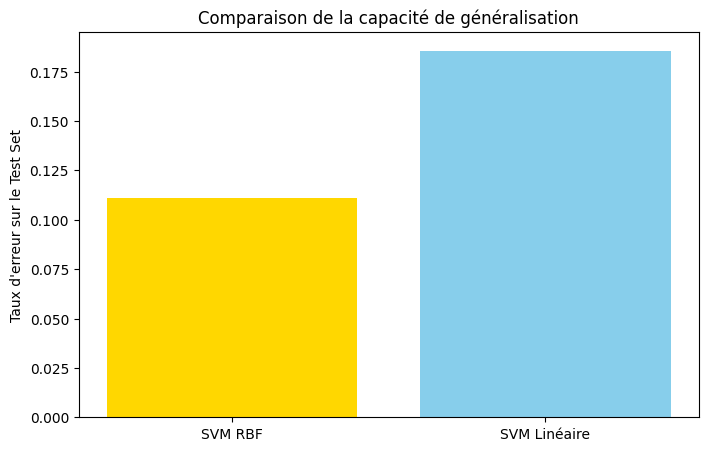

In [52]:
error_rbf = 1 - clf_rbf.score(X_test, Y_test)
error_linear = 1 - accuracy_linear_test

models = ['SVM RBF', 'SVM Linéaire']
errors = [error_rbf, error_linear]

plt.figure(figsize=(8, 5))
plt.bar(models, errors, color=['gold', 'skyblue'])
plt.ylabel('Taux d\'erreur sur le Test Set')
plt.title('Comparaison de la capacité de généralisation')
plt.show()